# Tourism Experience Analytics — Exploratory Data Analysis

In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline
m = pd.read_csv('../data/cleaned/master_clean.csv')
m.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,VisitModeLabel,UserContinent,UserRegion,UserCountry,UserCity,Attraction,AttractionType,AttractionRegion,AttractionCountry,AttractionAddress
0,3,70456,2022,10,2,640,5,Couples,Europe,Western Europe,United Kingdom,Guildford,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Bali,Indonesia,"Jl. Monkey Forest, Ubud 80571 Indonesia"
1,8,7567,2022,10,4,640,5,Friends,America,Northern America,Canada,Ontario,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Bali,Indonesia,"Jl. Monkey Forest, Ubud 80571 Indonesia"
2,9,79069,2022,10,3,640,5,Family,America,South America,Brazil,Brazil,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Bali,Indonesia,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,10,31019,2022,10,3,640,3,Family,Europe,Central Europe,Switzerland,Zurich,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Bali,Indonesia,"Jl. Monkey Forest, Ubud 80571 Indonesia"
4,15,43611,2022,10,2,640,3,Couples,Europe,Western Europe,United Kingdom,Manchester,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Bali,Indonesia,"Jl. Monkey Forest, Ubud 80571 Indonesia"


## Rating distribution
Ratings are heavily skewed toward 4-5 (~79% of all records).

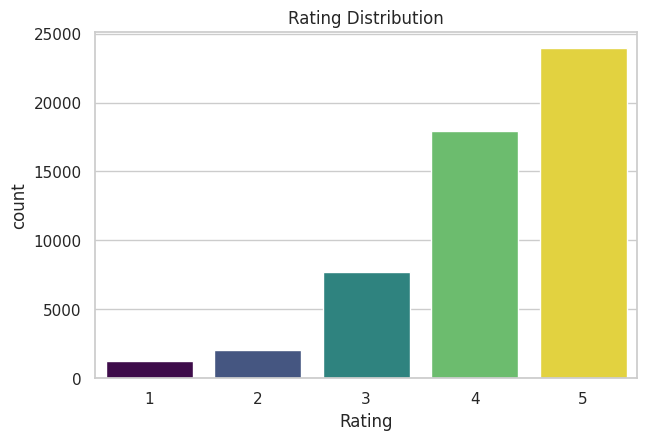

Rating
1     2.386170
2     3.844701
3    14.604194
4    33.942944
5    45.221991
Name: proportion, dtype: float64

In [2]:
plt.figure(figsize=(7,4.5))
sns.countplot(data=m, x='Rating', hue='Rating', palette='viridis', legend=False)
plt.title('Rating Distribution'); plt.show()
m.Rating.value_counts(normalize=True).sort_index()*100

## Visit mode distribution
Severe imbalance: Business is only ~1.2% of records.

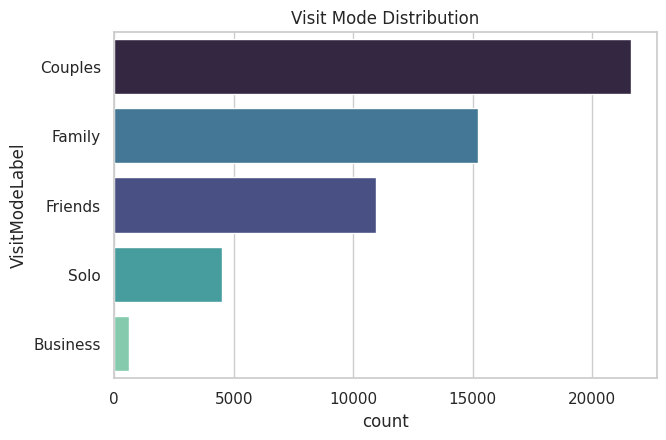

VisitModeLabel
Couples     40.846401
Family      28.749292
Friends     20.678254
Solo         8.549027
Business     1.177026
Name: proportion, dtype: float64

In [3]:
plt.figure(figsize=(7,4.5))
order = m.VisitModeLabel.value_counts().index
sns.countplot(data=m, y='VisitModeLabel', order=order, hue='VisitModeLabel', palette='mako', legend=False)
plt.title('Visit Mode Distribution'); plt.show()
m.VisitModeLabel.value_counts(normalize=True)*100

## Attraction type performance

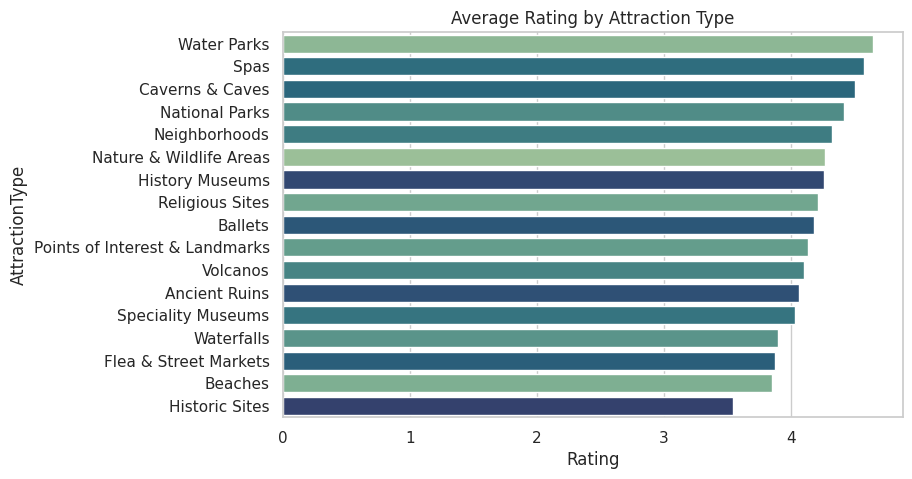

In [4]:
plt.figure(figsize=(8,5))
order2 = m.groupby('AttractionType').Rating.mean().sort_values(ascending=False).index
sns.barplot(data=m, y='AttractionType', x='Rating', order=order2, hue='AttractionType', palette='crest', legend=False, errorbar=None)
plt.title('Average Rating by Attraction Type'); plt.show()

## Time trends — COVID collapse is visible

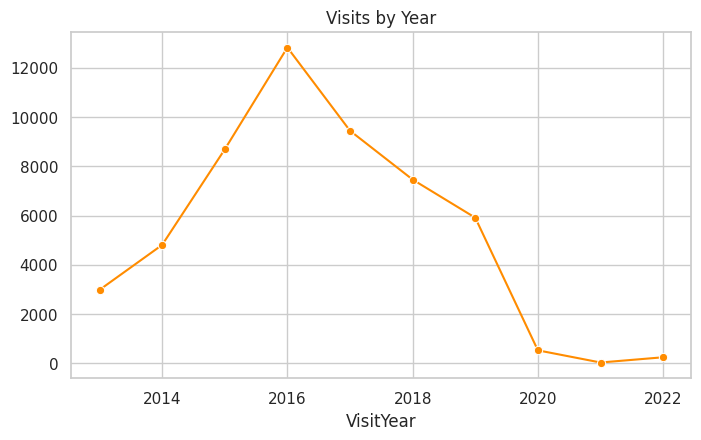

In [5]:
yearly = m.groupby('VisitYear').size()
plt.figure(figsize=(8,4.5))
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='darkorange')
plt.title('Visits by Year'); plt.show()

## User geography

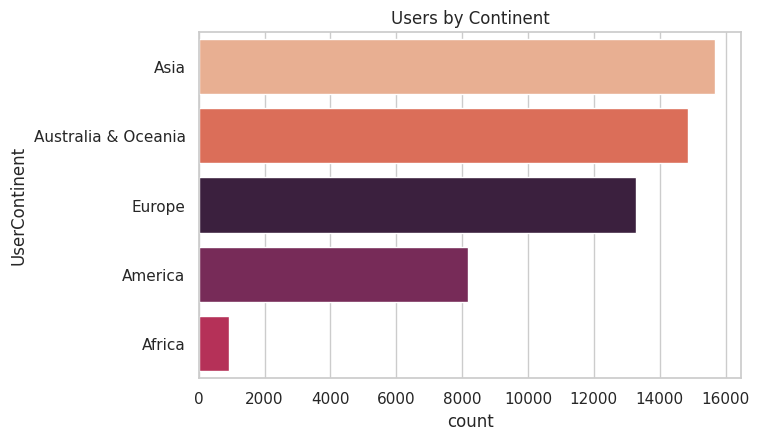

In [6]:
plt.figure(figsize=(7,4.5))
order3 = m.UserContinent.value_counts().index
sns.countplot(data=m, y='UserContinent', order=order3, hue='UserContinent', palette='rocket', legend=False)
plt.title('Users by Continent'); plt.show()

## Correlation heatmap (engineered numeric features vs Rating)

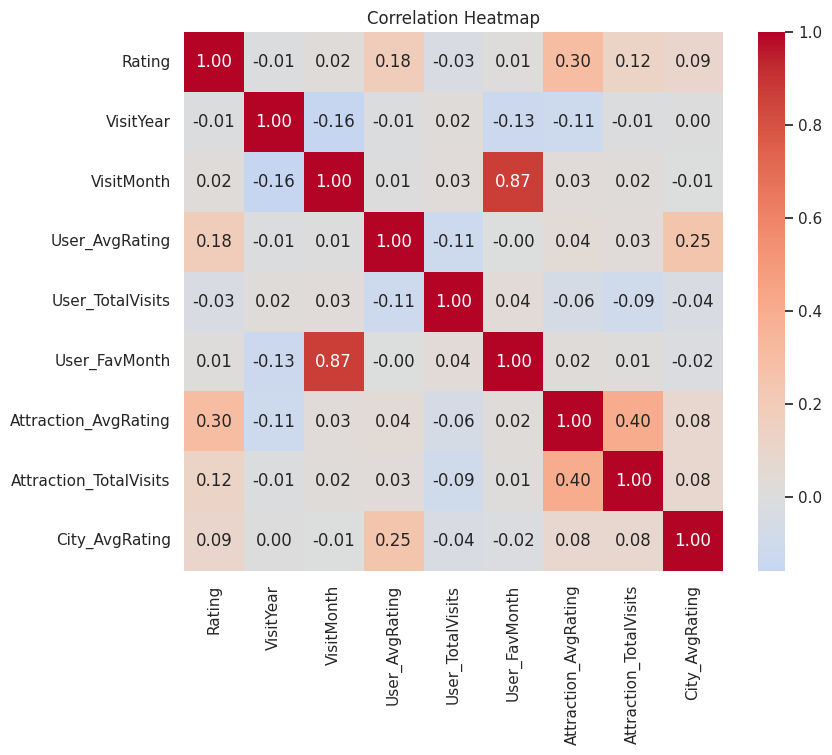

Rating                    1.000000
Attraction_AvgRating      0.299574
User_AvgRating            0.177310
Attraction_TotalVisits    0.120299
City_AvgRating            0.094083
VisitMonth                0.019217
User_FavMonth             0.011813
VisitYear                -0.006260
User_TotalVisits         -0.028474
Name: Rating, dtype: float64

In [7]:
mf = pd.read_csv('../data/cleaned/master_features.csv')
num_cols = ['Rating','VisitYear','VisitMonth','User_AvgRating','User_TotalVisits','User_FavMonth',
            'Attraction_AvgRating','Attraction_TotalVisits','City_AvgRating']
corr = mf[num_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap'); plt.show()
corr['Rating'].sort_values(ascending=False)

## Key takeaways
- Rating is skewed positive; regression ceiling is limited by this.
- VisitMode is imbalanced; Business will be hard to classify.
- Attraction_AvgRating and User_AvgRating (leak-safe engineered features) correlate most strongly with Rating — stronger than any raw demographic field.
- Clear COVID-19 shock in 2020-2021 visit counts.